# EDA — Step by Step

**EDA = Exploratory Data Analysis.** It just means: look at your data before you
build a model.

**The rule:** you are not making pretty pictures. You are answering questions.
Every chart in this notebook exists to answer one question. If a chart does not
change what you will do next, delete it.

**How to use this notebook:** run one cell at a time (Shift + Enter). Read the
output. Then read the note under it. Do not run everything at once.

**Before you start:** pick the kernel `Python (houseprice)` from the top-right
corner. If you do not, `import pandas` will fail.

## Step 1 — Load the data and look at it

Always look at the raw rows first. Never trust a summary before you have seen actual data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1 lakh = 100,000. We divide prices by this so numbers are readable.
LAKH = 100_000

df = pd.read_csv("../data/processed/mumbai_clean.csv")

print("Rows:", len(df))
print("Columns:", df.shape[1])
df.head()

Rows: 48302
Columns: 14


,title,price,area,locality,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,latitude,longitude,age_is_zero,has_balcony
0,Octave Parijas Horizon,6600283,757,Kalyan,Apartment,2,2,0,Unfurnished,0,19.244410,73.123253,1,0
1,Shakti Siyara Heights,6169841,652,Kalyan,Apartment,2,2,0,Unfurnished,0,19.257294,73.148872,1,0
2,Bhagwati Bhagwati Celeste,4599936,396,Dombivali,Apartment,1,1,0,Unfurnished,0,19.209026,73.081276,1,0
3,Relcon Ridhi Sidhi Sadan Of Ridhi Sidhi Co Ope...,51980000,1130,Ville Parle,Apartment,3,3,0,Unfurnished,0,19.097841,72.851158,1,0
4,J P Ruchita Bliss,3915000,435,Nala Sopara,Apartment,1,1,0,Unfurnished,0,19.420601,72.809319,1,0


`.head()` shows the first 5 rows. Check three things:

1. Do the numbers look sensible?
2. Are text columns spelled consistently?
3. Is anything obviously wrong?

In [2]:
# Column names, types, and how many values are missing
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48302 entries, 0 to 48301
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          39552 non-null  str    
 1   price          48302 non-null  int64  
 2   area           48302 non-null  int64  
 3   locality       48302 non-null  str    
 4   property_type  48302 non-null  str    
 5   bedroom_num    48302 non-null  int64  
 6   bathroom_num   48302 non-null  int64  
 7   balcony_num    48302 non-null  int64  
 8   furnished      48302 non-null  str    
 9   age            48302 non-null  int64  
 10  latitude       48218 non-null  float64
 11  longitude      48218 non-null  float64
 12  age_is_zero    48302 non-null  int64  
 13  has_balcony    48302 non-null  int64  
dtypes: float64(2), int64(8), str(4)
memory usage: 7.2 MB


## Step 2 — Look at the target

The **target** is the thing you want to predict. Here it is `price`.

Always study the target first. If you do not understand it, nothing else matters.

In [3]:
price_lakh = df.price / LAKH

print(f"Count  : {len(price_lakh):,}")
print(f"Min    : {price_lakh.min():,.1f} lakh")
print(f"25%    : {price_lakh.quantile(0.25):,.1f} lakh")
print(f"Median : {price_lakh.median():,.1f} lakh")
print(f"Mean   : {price_lakh.mean():,.1f} lakh")
print(f"75%    : {price_lakh.quantile(0.75):,.1f} lakh")
print(f"Max    : {price_lakh.max():,.1f} lakh")

Count  : 48,302
Min    : 9.0 lakh
25%    : 75.0 lakh
Median : 130.0 lakh
Mean   : 214.3 lakh
75%    : 230.0 lakh
Max    : 13,537.2 lakh


**Look at mean vs median.**

- **Median** = the middle value. Half the flats cost less, half cost more.
- **Mean** = the average.

If they are close, the data is balanced. If the mean is much higher, a few very
expensive flats are pulling it up.

Here the mean is much higher than the median. That is your first real finding.

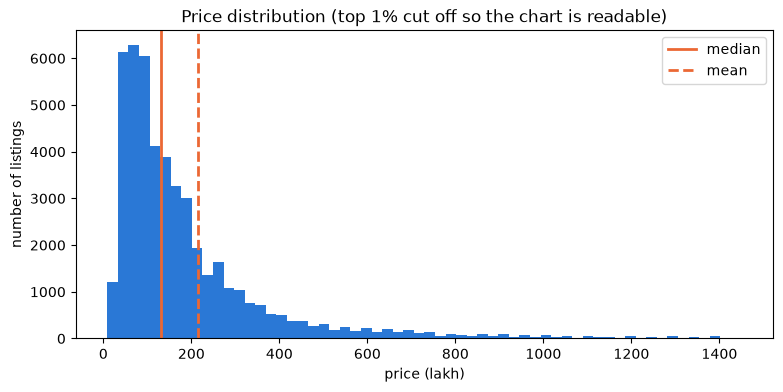

In [4]:
# Draw it, because a number does not show you the shape
fig, ax = plt.subplots(figsize=(9, 4))

# Cut off the top 1% so one huge listing does not squash everything else.
cut = price_lakh.quantile(0.99)
ax.hist(price_lakh[price_lakh <= cut], bins=60, color="#2a78d6")

ax.axvline(price_lakh.median(), color="#eb6834", lw=2, label="median")
ax.axvline(price_lakh.mean(), color="#eb6834", lw=2, ls="--", label="mean")
ax.set_xlabel("price (lakh)")
ax.set_ylabel("number of listings")
ax.set_title("Price distribution (top 1% cut off so the chart is readable)")
ax.legend()
plt.show()

This shape is called **right-skewed**: a tall bunch on the left, a long thin tail
going right.

Note that we cut off the top 1%. **Always say when you cut something off.**
Hiding data without saying so is dishonest.

## Step 3 — Measure the skew, then fix it

**Skew** is a number that says how lopsided the data is.

- 0 = perfectly balanced
- above 1 = clearly leaning right
- above 5 = very lopsided

In [5]:
print(f"Skew of price      : {df.price.skew():.2f}")
print(f"Skew of log(price) : {np.log(df.price).skew():.2f}")

Skew of price      : 10.47
Skew of log(price) : 0.56


**Why we take the log.**

Most models try to make big mistakes small. A mistake is measured by squaring it,
so a ₹10 crore mistake counts 10,000 times more than a ₹10 lakh mistake. The
model will then spend all its effort on the handful of very expensive flats and
do a bad job on the normal ones.

Log squashes big numbers. `log(1 crore)` and `log(100 crore)` are much closer
together than the raw numbers are.

Another way to see it: on a log scale, the model cares about **percentage**
mistakes, not rupee mistakes. Being ₹50 lakh wrong on a ₹60 lakh flat is a
disaster. Being ₹50 lakh wrong on a ₹50 crore flat is fine. Log understands that
difference. Raw rupees do not.

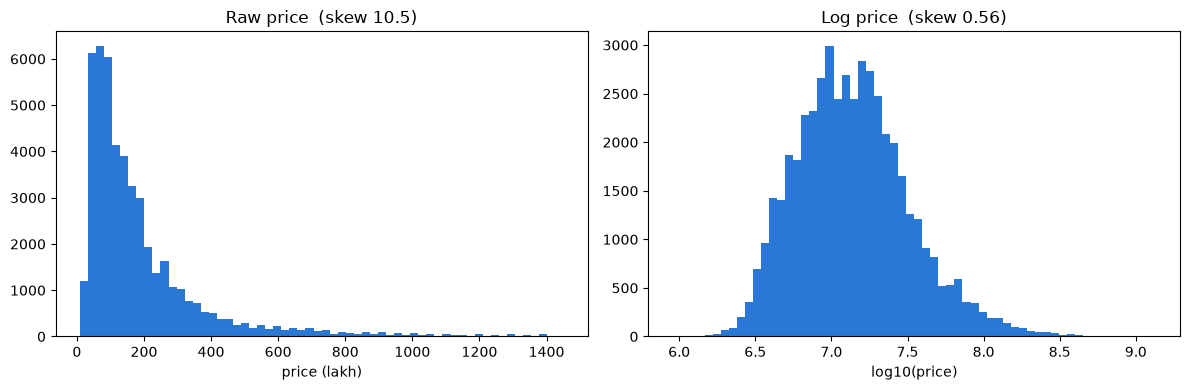

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(price_lakh[price_lakh <= cut], bins=60, color="#2a78d6")
ax1.set_title(f"Raw price  (skew {df.price.skew():.1f})")
ax1.set_xlabel("price (lakh)")

ax2.hist(np.log10(df.price), bins=60, color="#2a78d6")
ax2.set_title(f"Log price  (skew {np.log(df.price).skew():.2f})")
ax2.set_xlabel("log10(price)")

plt.tight_layout()
plt.show()

The right side is roughly bell-shaped. That is what we want.

**Note:** we have not decided anything yet. We have found evidence that the log
will help. We will test it properly in Phase 6.

## Step 4 — Look at every number column

Do not do this one column at a time by hand. Loop over them.

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
price,48302.0,21428795.54,33765713.22,902160.00,7500000.00,13000000.00,23000000.00,1.353723e+09
area,48302.0,982.75,639.74,150.00,612.00,828.50,1150.00,1.470000e+04
bedroom_num,48302.0,2.04,0.93,0.00,1.00,2.00,3.00,1.000000e+01
bathroom_num,48302.0,2.14,0.86,1.00,2.00,2.00,3.00,1.000000e+01
balcony_num,48302.0,0.15,0.57,0.00,0.00,0.00,0.00,8.000000e+00
age,48302.0,2.35,4.43,0.00,0.00,0.00,3.00,5.700000e+01
latitude,48218.0,19.15,0.11,18.75,19.07,19.16,19.23,1.992000e+01
longitude,48218.0,72.94,0.10,72.74,72.86,72.91,73.00,7.349000e+01
age_is_zero,48302.0,0.62,0.49,0.00,0.00,1.00,1.00,1.000000e+00
has_balcony,48302.0,0.08,0.27,0.00,0.00,0.00,0.00,1.000000e+00


Read this table for **impossible values**. Ask yourself for each row:

- Can the minimum really be that low?
- Can the maximum really be that high?
- Is the mean close to the median (the 50% column), or far from it?

We already cleaned this data in Phase 4, so nothing should look broken. If you
run this on raw data, plenty will.

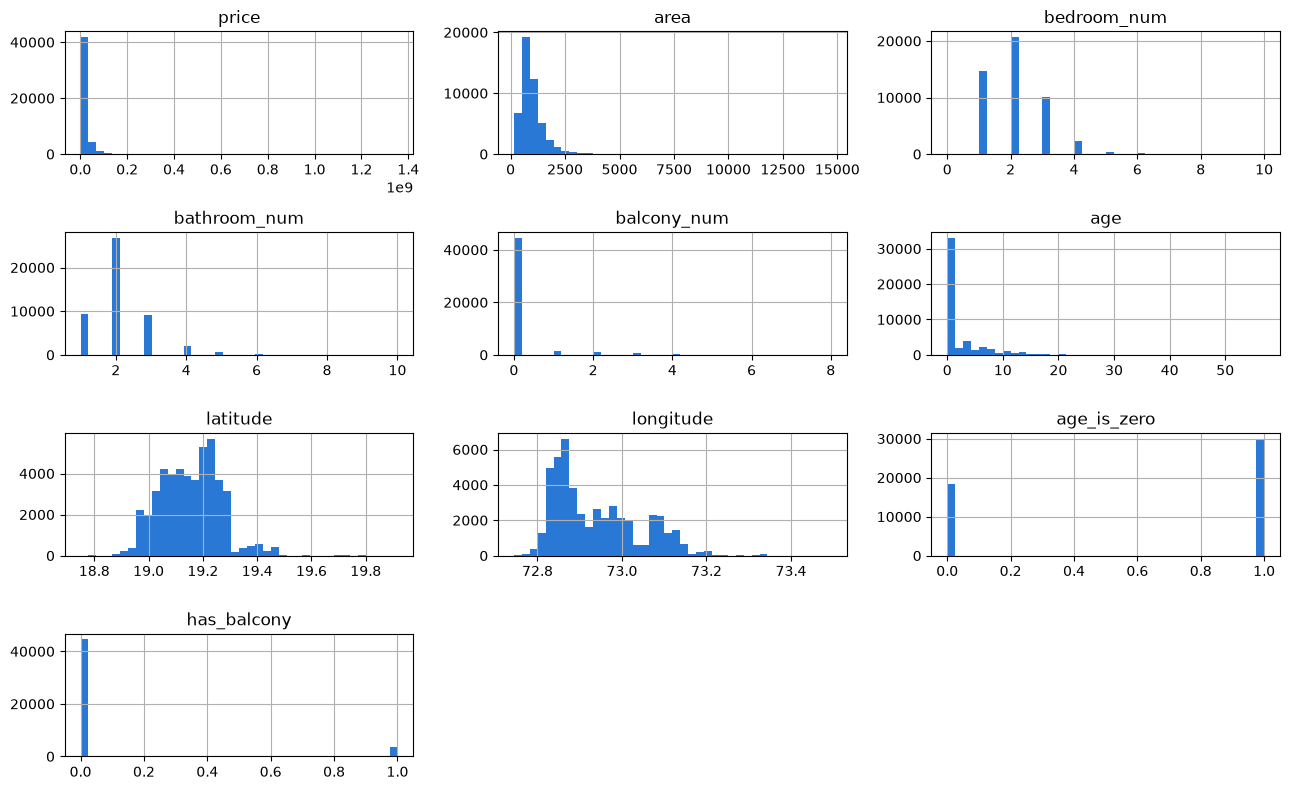

In [8]:
# Draw all the number columns at once to see their shapes
df[num_cols].hist(bins=40, figsize=(13, 8), color="#2a78d6")
plt.tight_layout()
plt.show()

## Step 5 — Look at every text column

For text, `describe()` is useless. You want to know how many different values
exist and which ones are common.

In [9]:
text_cols = df.select_dtypes(include=["object", "string"]).columns

for col in text_cols:
    n = df[col].nunique()
    print(f"--- {col}: {n:,} different values ---")
    print(df[col].value_counts().head(5).to_string())
    print()

--- title: 8,506 different values ---
title
Runwal Bliss                139
Piramal Vaikunth Thane      123
Radius Ten BKC              111
Hiranandani Fortune City    109
Gurukrupa Marina Enclave    107

--- locality: 365 different values ---
locality
Thane        5270
Mira Road    3155
Kandivali    2034
Andheri      2022
Kharghar     1881

--- property_type: 5 different values ---
property_type
Apartment            47793
Independent House      215
Villa                  186
Independent Floor      106
Studio Apartment         2

--- furnished: 3 different values ---
furnished
Unfurnished       31259
Semi-Furnished    13151
Furnished          3892



The important number here is **how many different values**.

- 3 values (like `furnished`) is easy to handle.
- 403 values (like `locality`) is a problem we have to solve in Phase 8.

## Step 6 — Does area affect price?

Now we move from single columns to **pairs** of columns. This is where the real
work starts.

For two number columns, use a scatter plot. But we have 51,715 rows, and dots
will pile on top of each other and hide where the data actually sits.

So we use a **hexbin**: split the chart into small hexagons and colour each one
by how many points fall inside it.

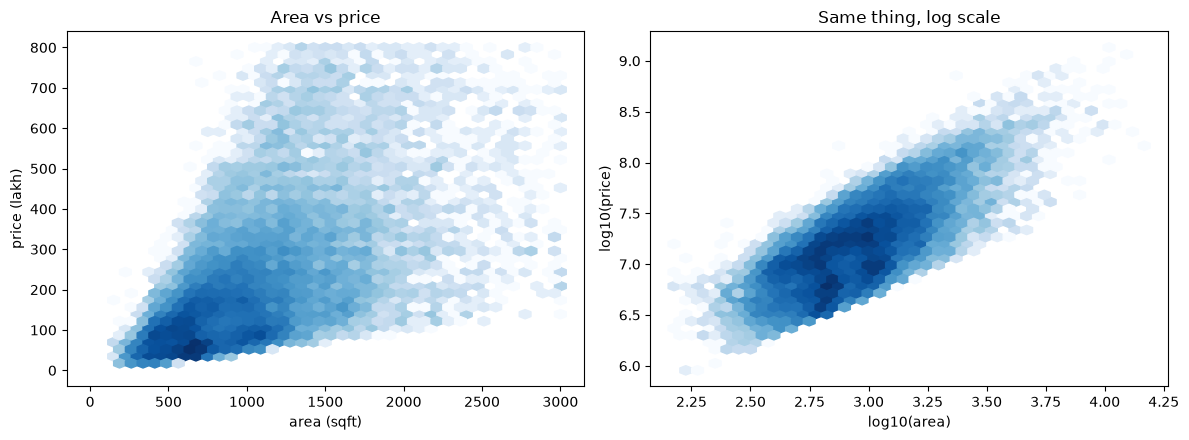

Correlation between area and price: 0.713
That means area explains about 50.8% of the price differences.


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.hexbin(df.area, df.price / LAKH, gridsize=40, cmap="Blues",
           bins="log", mincnt=1, extent=(0, 3000, 0, 800))
ax1.set_xlabel("area (sqft)")
ax1.set_ylabel("price (lakh)")
ax1.set_title("Area vs price")

ax2.hexbin(np.log10(df.area), np.log10(df.price), gridsize=40,
           cmap="Blues", bins="log", mincnt=1)
ax2.set_xlabel("log10(area)")
ax2.set_ylabel("log10(price)")
ax2.set_title("Same thing, log scale")

plt.tight_layout()
plt.show()

r = df.price.corr(df.area)
print(f"Correlation between area and price: {r:.3f}")
print(f"That means area explains about {r**2:.1%} of the price differences.")

**Correlation** is a number from -1 to +1 that says how strongly two things move
together. 0.7 sounds strong.

But square it and you get 0.497. **Area explains under half of the price
differences.** The other half is something else.

Look at the left chart. It is a **funnel**, not a line. At 500 sqft prices are
close together. At 1,500 sqft they run from ₹50 lakh to over ₹8 crore. Same
size, very different price.

The missing piece is **where** the flat is.

## Step 7 — Does BHK affect price?

BHK is a number, but it only takes a few values (1, 2, 3...). So treat it like a
category and group by it.

In [11]:
bhk = df[df.bedroom_num.between(1, 5)]

table = bhk.groupby("bedroom_num").agg(
    listings=("price", "size"),
    median_price_lakh=("price", lambda x: round(x.median() / LAKH, 1)),
    median_area=("area", "median"),
)
table

,listings,median_price_lakh,median_area
bedroom_num,,,
1,14745,65.0,550.0
2,20669,140.0,863.0
3,10027,270.0,1323.0
4,2267,575.0,2128.0
5,410,910.0,3000.0


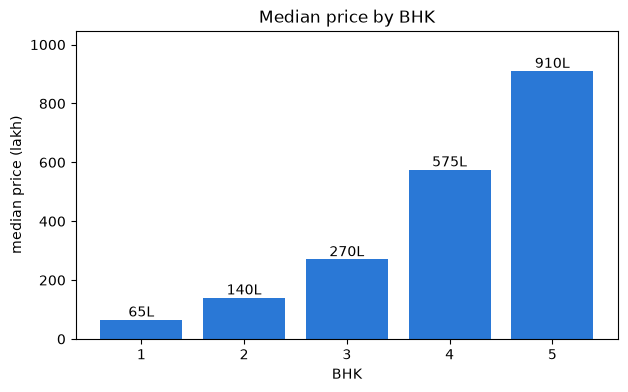

5 BHK is 14.0 times the price of 1 BHK


In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
med = bhk.groupby("bedroom_num").price.median() / LAKH
bars = ax.bar(med.index.astype(str), med.values, color="#2a78d6")

# Put the number on top of each bar so nobody has to guess
for b, v in zip(bars, med.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,.0f}L",
            ha="center", va="bottom")

ax.set_xlabel("BHK")
ax.set_ylabel("median price (lakh)")
ax.set_title("Median price by BHK")
ax.margins(y=0.15)
plt.show()

print(f"5 BHK is {med[5]/med[1]:.1f} times the price of 1 BHK")

5 BHK is about **15 times** the price of 1 BHK, not 5 times.

The line curves upward. This matters: a plain straight-line model cannot draw a
curve. Remember this in Phase 11.

## Step 8 — Does location affect price?

This is the big one.

We compare **price per sqft**, not total price. Why? Because South Mumbai flats
are both expensive *and* often bigger. If we compared total price we would not
know which of the two is causing the difference. Dividing by area removes the
size effect.

In [13]:
df["ppsf"] = df.price / df.area

loc = df.groupby("locality").agg(
    listings=("price", "size"),
    median_ppsf=("ppsf", "median"),
)

# Only keep localities with enough listings. A median from 5 rows is noise,
# not information.
loc = loc[loc.listings >= 200].sort_values("median_ppsf")

print("MOST EXPENSIVE:")
print(loc.tail(5).round(0).to_string())
print("\nCHEAPEST:")
print(loc.head(5).round(0).to_string())
print(f"\nGap: {loc.median_ppsf.max() / loc.median_ppsf.min():.1f} times")

MOST EXPENSIVE:
             listings  median_ppsf
locality                          
Bandra            708      41997.0
Byculla           470      43696.0
Matunga           260      45004.0
Lower Parel       349      46981.0
Prabhadevi        207      47917.0

CHEAPEST:
             listings  median_ppsf
locality                          
Ambernath         268       5826.0
Naigaon           575       6194.0
Taloja            504       6548.0
Nala Sopara       236       7127.0
Vasai             660       7285.0

Gap: 8.2 times


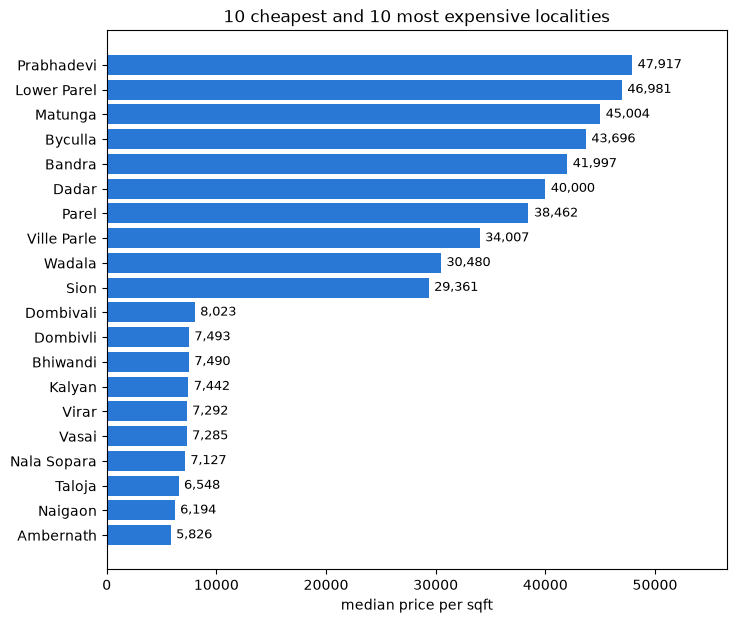

In [14]:
band = pd.concat([loc.head(10), loc.tail(10)])

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(band.index, band.median_ppsf, color="#2a78d6")
for y, v in enumerate(band.median_ppsf):
    ax.text(v + 500, y, f"{v:,.0f}", va="center", fontsize=9)
ax.set_xlabel("median price per sqft")
ax.set_title("10 cheapest and 10 most expensive localities")
ax.margins(x=0.18)
plt.show()

A **13 times** gap, and this is price *per sqft*, so it is not about size.

Location is the strongest thing in this dataset. We can measure exactly how
strong with the cell below.

In [15]:
# What share of the price differences can locality alone account for?
y = np.log(df.price)
grand_mean = y.mean()
groups = df.assign(y=y).groupby("locality").y.agg(["mean", "size"])

between = ((groups["mean"] - grand_mean) ** 2 * groups["size"]).sum()
total = ((y - grand_mean) ** 2).sum()

print(f"Locality alone accounts for {between/total:.1%} of price differences")
print(f"Area alone accounts for     {df.price.corr(df.area)**2:.1%}")

Locality alone accounts for 58.9% of price differences
Area alone accounts for     50.8%


## Step 9 — Correlation between all number columns

A quick way to see which numbers move together.

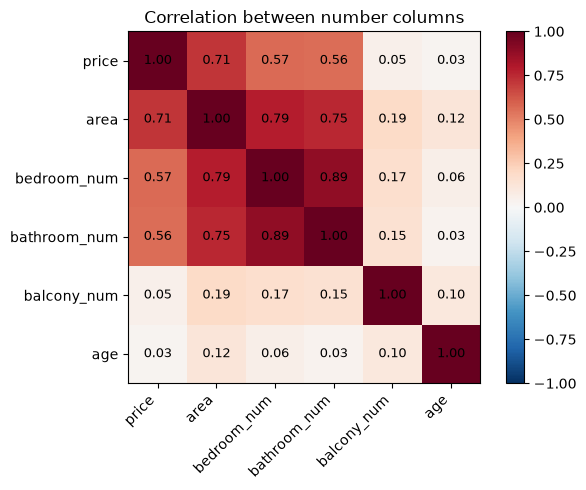

In [16]:
corr = df[["price", "area", "bedroom_num", "bathroom_num",
           "balcony_num", "age"]].corr()

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)

# Write the actual number in each box. A colour alone is hard to read.
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=9)

ax.set_title("Correlation between number columns")
plt.colorbar(im)
plt.tight_layout()
plt.show()

**Careful with this chart.** Correlation only finds **straight-line**
relationships. Two columns can be strongly connected in a curved way and still
show a correlation near 0. Never conclude "no relationship" from a low
correlation alone.

## Step 10 — Look for traps

This is the step most people skip, and it is the most important one.

A **trap** is when two columns look related, but something else is causing both.
The proper name is a **confounding variable**.

Let us test furnishing.

In [17]:
check = df.groupby("furnished").agg(
    listings=("price", "size"),
    median_price_lakh=("price", lambda x: round(x.median()/LAKH, 1)),
    median_area=("area", "median"),
    median_ppsf=("ppsf", "median"),
).round(0)
check

,listings,median_price_lakh,median_area,median_ppsf
furnished,,,,
Furnished,3892,220.0,1025.0,23593.0
Semi-Furnished,13151,129.0,950.0,14296.0
Unfurnished,31259,125.0,752.0,16875.0


Read this table carefully.

**By total price**, Furnished flats cost far more than Unfurnished. Easy
conclusion: furnishing adds a lot of value.

**By price per sqft**, Semi-Furnished is *cheaper* than Unfurnished.

Both cannot be true if furnishing is what drives the price. So something else is
going on: furnished flats are **bigger** and sit in **more expensive areas**.
The first column was mostly measuring size and location, not furnishing.

Let us check it is not just a size-mix effect, by looking at 2 BHK only.

In [18]:
two_bhk = df[df.bedroom_num == 2]
two_bhk.groupby("furnished").agg(
    listings=("price", "size"),
    median_ppsf=("ppsf", "median"),
).round(0)

,listings,median_ppsf
furnished,,
Furnished,1538,20602.0
Semi-Furnished,5504,14458.0
Unfurnished,13627,17472.0


Same pattern inside a single flat size. So it is real, not a mixing artefact.

**The rule to remember:** two things moving together does not mean one causes
the other. Look for a third thing driving both.

Now try the same test on `age`.

In [19]:
aged = df[df.age > 0].copy()
aged["band"] = pd.cut(aged.age, [0, 5, 10, 15, 20, 60],
                      labels=["1-5", "6-10", "11-15", "16-20", "21+"])

aged.groupby("band", observed=True).agg(
    listings=("price", "size"),
    median_ppsf=("ppsf", "median"),
).round(0)

,listings,median_ppsf
band,,
1-5,10244,17301.0
6-10,4754,12569.0
11-15,2201,13438.0
16-20,732,17376.0
21+,381,17568.0


Older buildings are **more** expensive per sqft. That seems backwards.

Likely reason: old buildings are in South and Central Mumbai (expensive), new
construction is in the far suburbs (cheap). Age is quietly standing in for
location again.

We cannot prove this from the table. It is a reasonable explanation, not a
proven fact. Say it that way.

## Step 11 — Write down what you found

This is not optional. If you do not write it down, you will forget it, and none
of it will reach your README or your interview answers.

For each finding write: **what you saw**, **the number**, and **what you will do
about it**.

In [20]:
findings = [
    ("Price is very skewed",       "skew 10.53 -> 0.35 with log", "test log target in Phase 6"),
    ("Area is not enough",         "r=0.70, r2=0.50",             "need location too"),
    ("BHK curve bends upward",     "5BHK = 15x 1BHK",             "avoid plain linear model"),
    ("Location is the strongest",  "63.7% of variance",           "encoding matters most, Phase 8"),
    ("Furnishing is a trap",       "semi < unfurnished per sqft", "never call it causation"),
    ("Age is a trap too",          "old = more expensive/sqft",   "it is a proxy for location"),
]

out = pd.DataFrame(findings, columns=["what I saw", "the number", "what I will do"])
out

,what I saw,the number,what I will do
0,Price is very skewed,skew 10.53 -> 0.35 with log,test log target in Phase 6
1,Area is not enough,"r=0.70, r2=0.50",need location too
2,BHK curve bends upward,5BHK = 15x 1BHK,avoid plain linear model
3,Location is the strongest,63.7% of variance,"encoding matters most, Phase 8"
4,Furnishing is a trap,semi < unfurnished per sqft,never call it causation
5,Age is a trap too,old = more expensive/sqft,it is a proxy for location


## Checklist — the EDA method for any dataset

You can reuse this on any project:

1. Load it and print actual rows
2. Study the target on its own — shape, middle, spread
3. Check the target for skew, and try a log if it is bad
4. Loop over number columns — look for impossible values
5. Loop over text columns — count how many different values
6. Plot each strong feature against the target
7. Group by each category and compare medians
8. Check correlation, but remember it only sees straight lines
9. **Hunt for traps** — is a third variable driving both?
10. Write down every finding with a number attached

**Two habits that matter more than any chart:**

- **Use median, not mean**, whenever the data is skewed. The mean lies when there
  are outliers.
- **Always show the sample size.** A median from 5 rows is not a fact.